# Setup

In [45]:
# importing libraries 
from pathlib import Path

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import sys

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.figsize"] = (10, 6)

In [46]:
# path vars and files
PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_PATH = DATA_DIR / "UNSW_NB15_testing-set.csv"
FEATURES_PATH = DATA_DIR / "NUSW-NB15_features.csv"

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

print("\nFiles found:")
for file in DATA_DIR.glob("*.csv"):
    print("-", file.name)

Project root: C:\Projects\Aeges-Q
Data directory: C:\Projects\Aeges-Q\data\raw

Files found:
- NUSW-NB15_features.csv
- UNSW-NB15_1.csv
- UNSW-NB15_2.csv
- UNSW-NB15_3.csv
- UNSW-NB15_4.csv
- UNSW-NB15_LIST_EVENTS.csv
- UNSW_NB15_testing-set.csv
- UNSW_NB15_training-set.csv


In [3]:
# train and test dataframes
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (82332, 45)
Testing shape: (175341, 45)


In [4]:
# Display the first few rows of the training dataframe
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0000,0.0000,0,0,0.0110,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0000,0.0000,0,0,0.0080,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0000,0.0000,0,0,0.0050,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0000,0.0000,0,0,0.0060,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0000,0.0000,0,0,0.0100,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [5]:
# columns
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [6]:
# training data information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

# Dataset Integrity Audit 

In [7]:
# verifying identiical schemas
print(
    "Schemas identical:",
    list(train_df.columns) == list(test_df.columns)
)

print("\nColumns only in train:")
print(set(train_df.columns) - set(test_df.columns))

print("\nColumns only in test:")
print(set(test_df.columns) - set(train_df.columns))

Schemas identical: True

Columns only in train:
set()

Columns only in test:
set()


In [8]:
# inspecting the tables
print("Binary label distribution:\n")
print(train_df["label"].value_counts())

Binary label distribution:

label
1    45332
0    37000
Name: count, dtype: int64


In [9]:
# binary label percentages 
print("\nBinary label percentages:\n")
print(
    train_df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Binary label percentages:

label
1   55.0600
0   44.9400
Name: proportion, dtype: float64


In [10]:
# inspecting attack categories 
print("\nAttack category distribution:\n")

print(
    train_df["attack_cat"]
    .value_counts()
) 


Attack category distribution:

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [11]:
pd.crosstab(
    train_df["attack_cat"],
    train_df["label"]
)

label,0,1
attack_cat,,
Analysis,0,677
Backdoor,0,583
DoS,0,4089
Exploits,0,11132
Fuzzers,0,6062
Generic,0,18871
Normal,37000,0
Reconnaissance,0,3496
Shellcode,0,378


In [12]:
# missing values 
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

print("Train missing values:")
display(
    train_missing[train_missing > 0]
    .sort_values(ascending=False)
)

print("\nTest missing values:")
display(
    test_missing[test_missing > 0]
    .sort_values(ascending=False)
)

Train missing values:


Series([], dtype: int64)


Test missing values:


Series([], dtype: int64)

In [13]:
# duplicate rows 
print(
    "Duplicate rows in train:",
    train_df.duplicated().sum()
)

print(
    "Duplicate rows in test:",
    test_df.duplicated().sum()
)

Duplicate rows in train: 0
Duplicate rows in test: 0


In [14]:
# duplicates excluding id column
feature_columns = [col for col in train_df.columns if col != "id"]

print(
    "Feature duplicates in train:",
    train_df[feature_columns].duplicated().sum()
)

print(
    "Feature duplicates in test:",
    test_df[feature_columns].duplicated().sum()
)

Feature duplicates in train: 26387
Feature duplicates in test: 67601


In [15]:
# unique values per column 
unique_counts = train_df.nunique().sort_values()

unique_counts

is_sm_ips_ports          2
label                    2
is_ftp_login             3
ct_ftp_cmd               3
state                    7
ct_state_ttl             7
trans_depth              8
dttl                     8
ct_flw_http_mthd         8
attack_cat              10
swin                    11
sttl                    11
service                 13
dwin                    14
ct_dst_sport_ltm        33
ct_dst_ltm              50
ct_src_dport_ltm        50
ct_src_ltm              50
ct_dst_src_ltm          57
ct_srv_dst              57
ct_srv_src              57
proto                  131
sloss                  253
dloss                  311
spkts                  420
dpkts                  436
response_body_len     1190
dmean                 1222
smean                 1282
dbytes                4034
sbytes                4489
ackdat               24020
synack               24934
tcprtt               26130
dinpkt               37617
djit                 38381
dtcpb                39108
s

In [16]:
low_cardinality = unique_counts[
    unique_counts <= 20
]

low_cardinality

is_sm_ips_ports      2
label                2
is_ftp_login         3
ct_ftp_cmd           3
state                7
ct_state_ttl         7
trans_depth          8
dttl                 8
ct_flw_http_mthd     8
attack_cat          10
swin                11
sttl                11
service             13
dwin                14
dtype: int64

In [17]:
# constant features
low_cardinality = unique_counts[
    unique_counts <= 20
]

low_cardinality

is_sm_ips_ports      2
label                2
is_ftp_login         3
ct_ftp_cmd           3
state                7
ct_state_ttl         7
trans_depth          8
dttl                 8
ct_flw_http_mthd     8
attack_cat          10
swin                11
sttl                11
service             13
dwin                14
dtype: int64

# Class and Attack Distribution

In [18]:
# Binary class distribution

label_counts = train_df["label"].value_counts().sort_index()

print(label_counts)

label_percentages = (
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nPercentages:")
print(label_percentages.round(2))

label
0    37000
1    45332
Name: count, dtype: int64

Percentages:
label
0   44.9400
1   55.0600
Name: proportion, dtype: float64


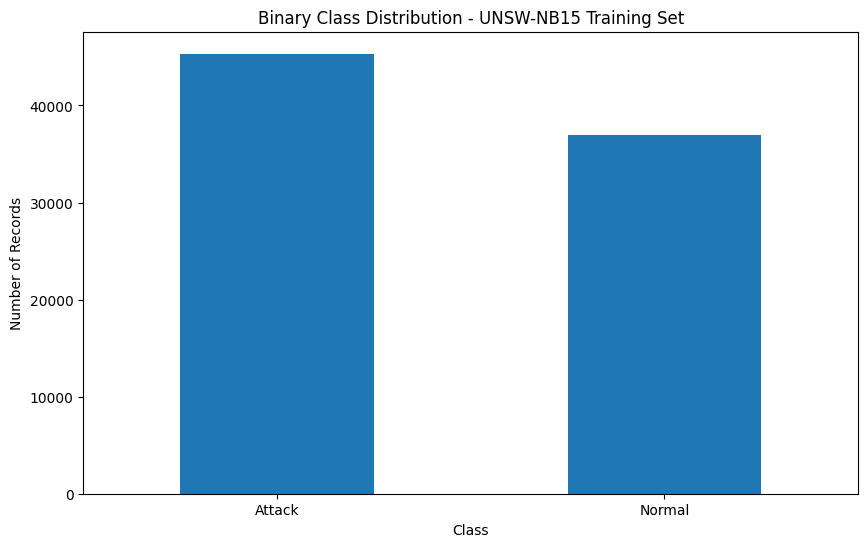

In [19]:
label_names = train_df["label"].map({
    0: "Normal",
    1: "Attack"
})

label_names.value_counts().plot(
    kind="bar",
    title="Binary Class Distribution - UNSW-NB15 Training Set",
    xlabel="Class",
    ylabel="Number of Records"
)

plt.xticks(rotation=0)
plt.show()

In [20]:
# Attack Category Distribution
attack_counts = train_df["attack_cat"].value_counts()

print(attack_counts)

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [21]:
attack_percentages = (
    train_df["attack_cat"]
    .value_counts(normalize=True)
    * 100
)

print(attack_percentages.round(2))

attack_cat
Normal           44.9400
Generic          22.9200
Exploits         13.5200
Fuzzers           7.3600
DoS               4.9700
Reconnaissance    4.2500
Analysis          0.8200
Backdoor          0.7100
Shellcode         0.4600
Worms             0.0500
Name: proportion, dtype: float64


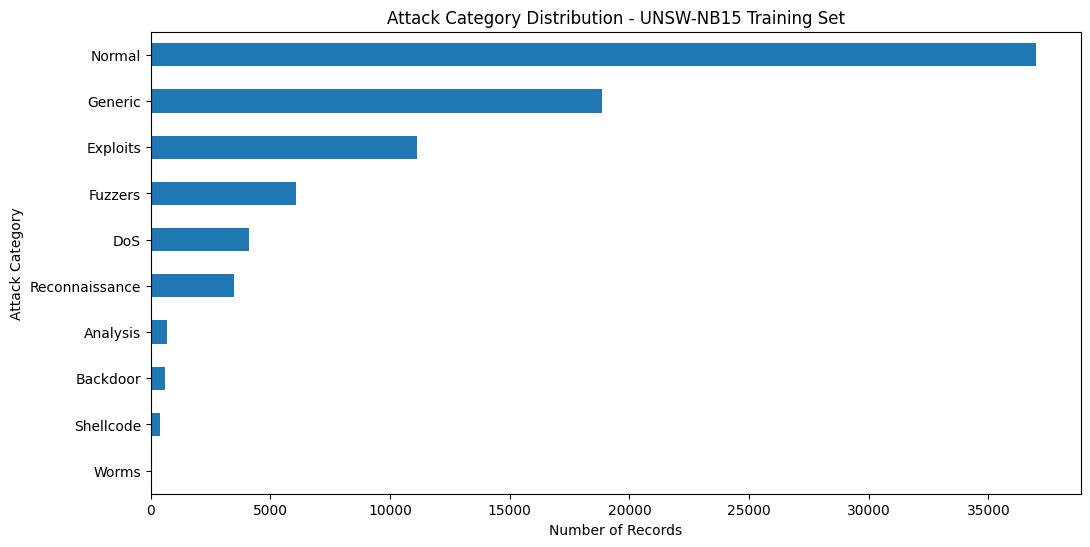

In [22]:
plt.figure(figsize=(12, 6))

attack_counts.sort_values().plot(
    kind="barh",
    title="Attack Category Distribution - UNSW-NB15 Training Set",
    xlabel="Number of Records",
    ylabel="Attack Category"
)

plt.show()

In [23]:
# Relationship Between Attack_Cat and Label
pd.crosstab(
    train_df["attack_cat"],
    train_df["label"]
)

label,0,1
attack_cat,,
Analysis,0,677
Backdoor,0,583
DoS,0,4089
Exploits,0,11132
Fuzzers,0,6062
Generic,0,18871
Normal,37000,0
Reconnaissance,0,3496
Shellcode,0,378


In [24]:
# dataset summary 
def dataset_summary(df, name):
    print(f"\n{'=' * 50}")
    print(name)
    print(f"{'=' * 50}")

    print("\nShape:")
    print(df.shape)

    print("\nBinary label distribution:")
    print(df["label"].value_counts())

    print("\nBinary label percentage:")
    print(
        (df["label"]
         .value_counts(normalize=True)
         * 100)
        .round(2)
    )

    print("\nAttack categories:")
    print(df["attack_cat"].value_counts())


dataset_summary(train_df, "TRAINING SET")

dataset_summary(test_df, "TESTING SET")


TRAINING SET

Shape:
(82332, 45)

Binary label distribution:
label
1    45332
0    37000
Name: count, dtype: int64

Binary label percentage:
label
1   55.0600
0   44.9400
Name: proportion, dtype: float64

Attack categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

TESTING SET

Shape:
(175341, 45)

Binary label distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Binary label percentage:
label
1   68.0600
0   31.9400
Name: proportion, dtype: float64

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: 

# Understnding the Features

## 2. Feature Type Analysis

The dataset contains:
- Identifier: `id`
- Categorical network features: `proto`, `service`, `state`
- Numerical network-flow features
- `attack_cat`: attack category metadata
- `label`: binary target

In [25]:
categorical_features = [
    "proto",
    "service",
    "state"
]

target_columns = [
    "attack_cat",
    "label"
]

id_column = "id"

numerical_features = [
    col for col in train_df.columns
    if col not in categorical_features + target_columns + [id_column]
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['proto', 'service', 'state']
Number of numerical features: 39


In [26]:
# inspect categorical features
for col in categorical_features:
    print(f"\n{'=' * 50}")
    print(f"{col.upper()}")
    print(f"{'=' * 50}")
    
    print("Unique values:", train_df[col].nunique())
    print(train_df[col].value_counts().head(20))


PROTO
Unique values: 131
proto
tcp        43095
udp        29418
unas        3515
arp          987
ospf         676
sctp         324
any           96
gre           88
rsvp          64
ipv6          61
sep           58
sun-nd        54
swipe         52
mobile        52
pim           52
xns-idp       34
leaf-1        34
bbn-rcc       34
prm           34
irtp          33
Name: count, dtype: int64

SERVICE
Unique values: 13
service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64

STATE
Unique values: 7
state
FIN    39339
INT    34163
CON     6982
REQ     1842
ACC        4
RST        1
CLO        1
Name: count, dtype: int64


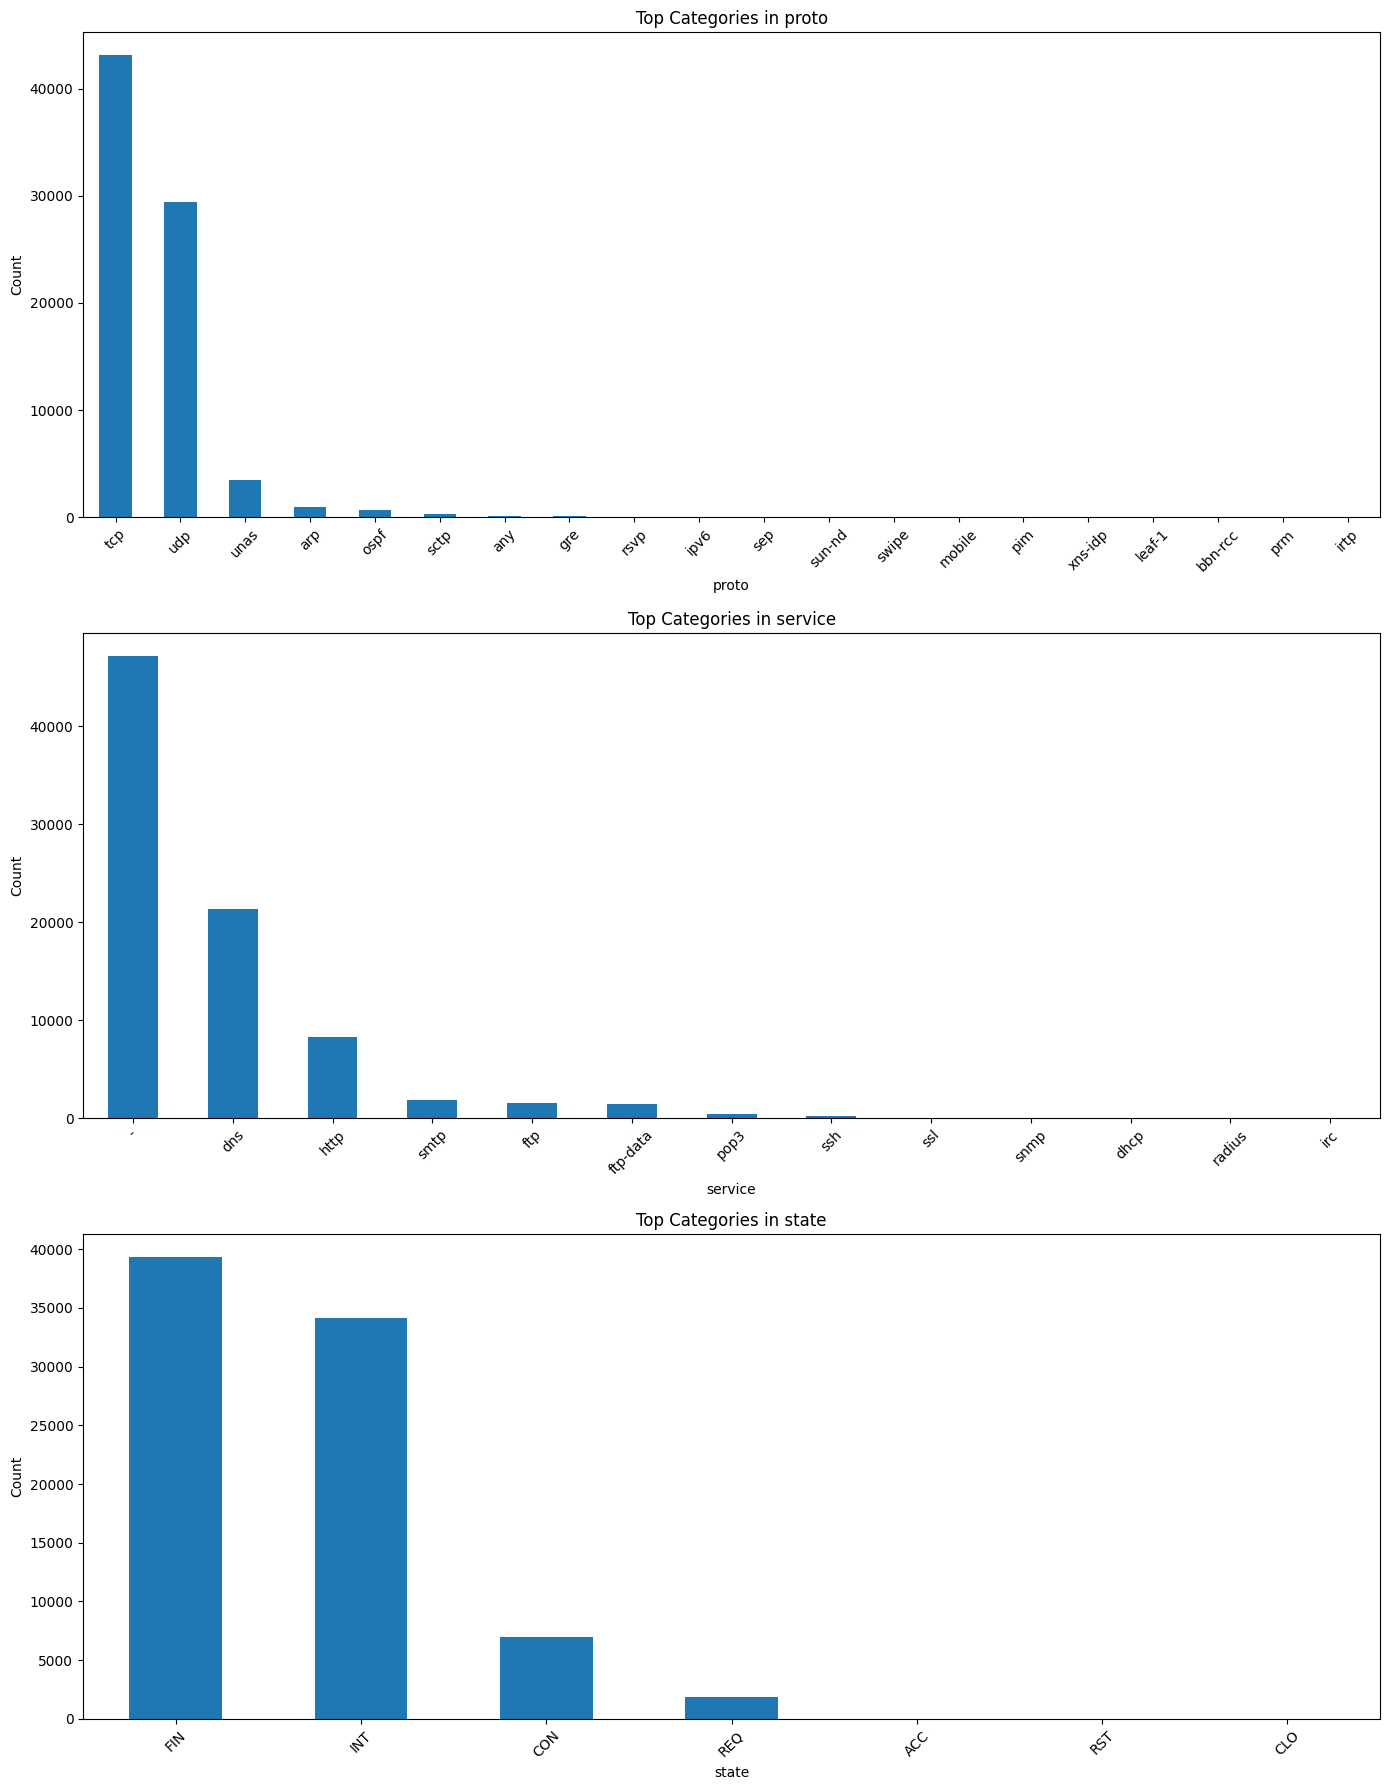

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, col in zip(axes, categorical_features):
    train_df[col].value_counts().head(20).plot(
        kind="bar",
        ax=ax
    )
    
    ax.set_title(f"Top Categories in {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [28]:
# numerical feature summary 
numerical_summary = train_df[numerical_features].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
dur,82332.0000,1.0068,4.7104,0.0000,0.0000,0.0141,0.7194,60.0000
spkts,82332.0000,18.6665,133.9164,1.0000,2.0000,6.0000,12.0000,10646.0000
dpkts,82332.0000,17.5459,115.5741,0.0000,0.0000,2.0000,10.0000,11018.0000
sbytes,82332.0000,7993.9082,171642.2619,24.0000,114.0000,534.0000,1280.0000,14355774.0000
dbytes,82332.0000,13233.7856,151471.4561,0.0000,0.0000,178.0000,956.0000,14657531.0000
rate,82332.0000,82410.8867,148620.3670,0.0000,28.6061,2650.1767,111111.1072,1000000.0030
sttl,82332.0000,180.9677,101.5134,0.0000,62.0000,254.0000,254.0000,255.0000
dttl,82332.0000,95.7130,116.6677,0.0000,0.0000,29.0000,252.0000,253.0000
sload,82332.0000,64549016.9141,179861832.6300,0.0000,11202.4668,577003.2188,65142856.0000,5268000256.0000
dload,82332.0000,630546.9590,2393000.5556,0.0000,0.0000,2112.9514,15858.0823,20821108.0000


In [29]:
numerical_summary[
    ["min", "max", "mean", "std", "50%"]
].sort_values("max", ascending=False)

,min,max,mean,std,50%
sload,0.0000,5268000256.0000,64549016.9141,179861832.6300,577003.2188
stcpb,0.0000,4294949667.0000,1084641551.1153,1390859761.6104,27888855.0000
dtcpb,0.0000,4294880717.0000,1073464670.8804,1381996192.0328,28569748.5000
dload,0.0000,20821108.0000,630546.9590,2393000.5556,2112.9514
dbytes,0.0000,14657531.0000,13233.7856,151471.4561,178.0000
sbytes,24.0000,14355774.0000,7993.9082,171642.2619,534.0000
response_body_len,0.0000,5242880.0000,1595.3719,38066.9723,0.0000
sjit,0.0000,1483830.9170,6363.0751,56724.0167,17.6239
rate,0.0000,1000000.0030,82410.8867,148620.3670,2650.1767
djit,0.0000,463199.2401,535.1804,3635.3054,0.0000


In [30]:
# check skewness
skewness = train_df[numerical_features].skew()

skewness.sort_values(
    key=lambda x: x.abs(),
    ascending=False
)

trans_depth         170.7944
response_body_len    74.6352
djit                 60.5623
dloss                54.4656
sbytes               53.7785
dbytes               52.5504
sloss                52.4653
dpkts                49.3041
spkts                47.7478
dinpkt               23.0130
sjit                 15.3494
synack               13.8097
ct_flw_http_mthd     12.5577
ct_ftp_cmd           11.2432
is_ftp_login         11.0423
ackdat                9.6287
dur                   9.5238
sload                 9.4884
is_sm_ips_ports       9.3218
sinpkt                9.2741
tcprtt                9.0603
dload                 4.7539
smean                 3.5441
rate                  3.4995
dmean                 3.1068
ct_src_dport_ltm      2.8568
ct_dst_ltm            2.6670
ct_dst_sport_ltm      2.5068
ct_src_ltm            2.4373
ct_dst_src_ltm        2.1890
ct_srv_dst            1.8989
ct_srv_src            1.8564
ct_state_ttl          1.5222
dtcpb                 0.9301
stcpb         

In [31]:
# identifying highly skewed features 
highly_skewed = skewness[
    skewness.abs() > 1
].sort_values(
    key=lambda x: x.abs(),
    ascending=False
)

print(
    f"Highly skewed features: {len(highly_skewed)}"
)

highly_skewed

Highly skewed features: 33


trans_depth         170.7944
response_body_len    74.6352
djit                 60.5623
dloss                54.4656
sbytes               53.7785
dbytes               52.5504
sloss                52.4653
dpkts                49.3041
spkts                47.7478
dinpkt               23.0130
sjit                 15.3494
synack               13.8097
ct_flw_http_mthd     12.5577
ct_ftp_cmd           11.2432
is_ftp_login         11.0423
ackdat                9.6287
dur                   9.5238
sload                 9.4884
is_sm_ips_ports       9.3218
sinpkt                9.2741
tcprtt                9.0603
dload                 4.7539
smean                 3.5441
rate                  3.4995
dmean                 3.1068
ct_src_dport_ltm      2.8568
ct_dst_ltm            2.6670
ct_dst_sport_ltm      2.5068
ct_src_ltm            2.4373
ct_dst_src_ltm        2.1890
ct_srv_dst            1.8989
ct_srv_src            1.8564
ct_state_ttl          1.5222
dtype: float64

In [32]:
# zero heavy features
zero_percentage = (
    (train_df[numerical_features] == 0)
    .mean()
    * 100
).sort_values(ascending=False)

zero_percentage

is_ftp_login        99.1765
ct_ftp_cmd          99.1741
is_sm_ips_ports     98.8874
response_body_len   93.1290
ct_flw_http_mthd    90.7934
trans_depth         90.7909
djit                50.4688
dloss               50.0462
ackdat              49.9927
synack              49.9526
tcprtt              49.9526
dwin                49.6818
dtcpb               49.6696
stcpb               49.6538
sloss               47.7579
swin                47.6570
sjit                46.9441
dttl                43.8068
dinpkt              43.7436
dload               43.7412
dmean               43.7327
dpkts               43.7327
dbytes              43.7327
ct_state_ttl        20.7028
sttl                 1.2729
sload                1.2134
rate                 1.2134
dur                  1.1539
sinpkt               0.2198
sbytes               0.0000
spkts                0.0000
ct_src_dport_ltm     0.0000
ct_dst_ltm           0.0000
ct_srv_src           0.0000
smean                0.0000
ct_dst_sport_ltm    

In [33]:
zero_heavy_features = zero_percentage[
    zero_percentage > 90
]

zero_heavy_features

is_ftp_login        99.1765
ct_ftp_cmd          99.1741
is_sm_ips_ports     98.8874
response_body_len   93.1290
ct_flw_http_mthd    90.7934
trans_depth         90.7909
dtype: float64

# Relationship with the Target

In [34]:
# normal vs attack statistically 
normal_df = train_df[train_df["label"] == 0]
attack_df = train_df[train_df["label"] == 1]

print("Normal traffic:", normal_df.shape)
print("Attack traffic:", attack_df.shape)

Normal traffic: (37000, 45)
Attack traffic: (45332, 45)


In [35]:
# median
comparison = pd.DataFrame({
    "normal_median": normal_df[numerical_features].median(),
    "attack_median": attack_df[numerical_features].median(),
    "normal_mean": normal_df[numerical_features].mean(),
    "attack_mean": attack_df[numerical_features].mean()
})

comparison

,normal_median,attack_median,normal_mean,attack_mean
dur,0.2228,0.0000,1.0127,1.0019
spkts,10.0000,2.0000,22.7770,15.3115
dpkts,8.0000,0.0000,25.4153,11.1229
sbytes,974.0000,200.0000,4072.3774,11194.6635
dbytes,354.0000,0.0000,18704.9302,8768.2347
rate,118.6255,100000.0025,28349.9867,126535.4191
sttl,62.0000,254.0000,124.3190,227.2044
dttl,29.0000,0.0000,108.4447,85.3214
sload,91269.6836,50666664.0000,39753387.6737,84787221.3148
dload,7679.0217,0.0000,1373613.4453,24055.7388


In [36]:
# absolute standardized mean difference 
feature_separation = []

for col in numerical_features:
    
    normal_mean = normal_df[col].mean()
    attack_mean = attack_df[col].mean()
    
    pooled_std = train_df[col].std()
    
    if pooled_std != 0:
        separation = abs(
            attack_mean - normal_mean
        ) / pooled_std
    else:
        separation = 0
        
    feature_separation.append(
        (col, separation)
    )

feature_separation_df = pd.DataFrame(
    feature_separation,
    columns=["feature", "separation_score"]
)

feature_separation_df = feature_separation_df.sort_values(
    "separation_score",
    ascending=False
)

feature_separation_df.head(20)

,feature,separation_score
6,sttl,1.0135
16,swin,0.8333
31,ct_dst_sport_ltm,0.7914
19,dwin,0.7423
30,ct_src_dport_ltm,0.6865
5,rate,0.6606
28,ct_state_ttl,0.6403
37,ct_srv_dst,0.5889
27,ct_srv_src,0.5834
18,dtcpb,0.5686


In [37]:
# Top 10 features 
top_features = feature_separation_df.head(10)["feature"].tolist()

top_features

['sttl',
 'swin',
 'ct_dst_sport_ltm',
 'dwin',
 'ct_src_dport_ltm',
 'rate',
 'ct_state_ttl',
 'ct_srv_dst',
 'ct_srv_src',
 'dtcpb']

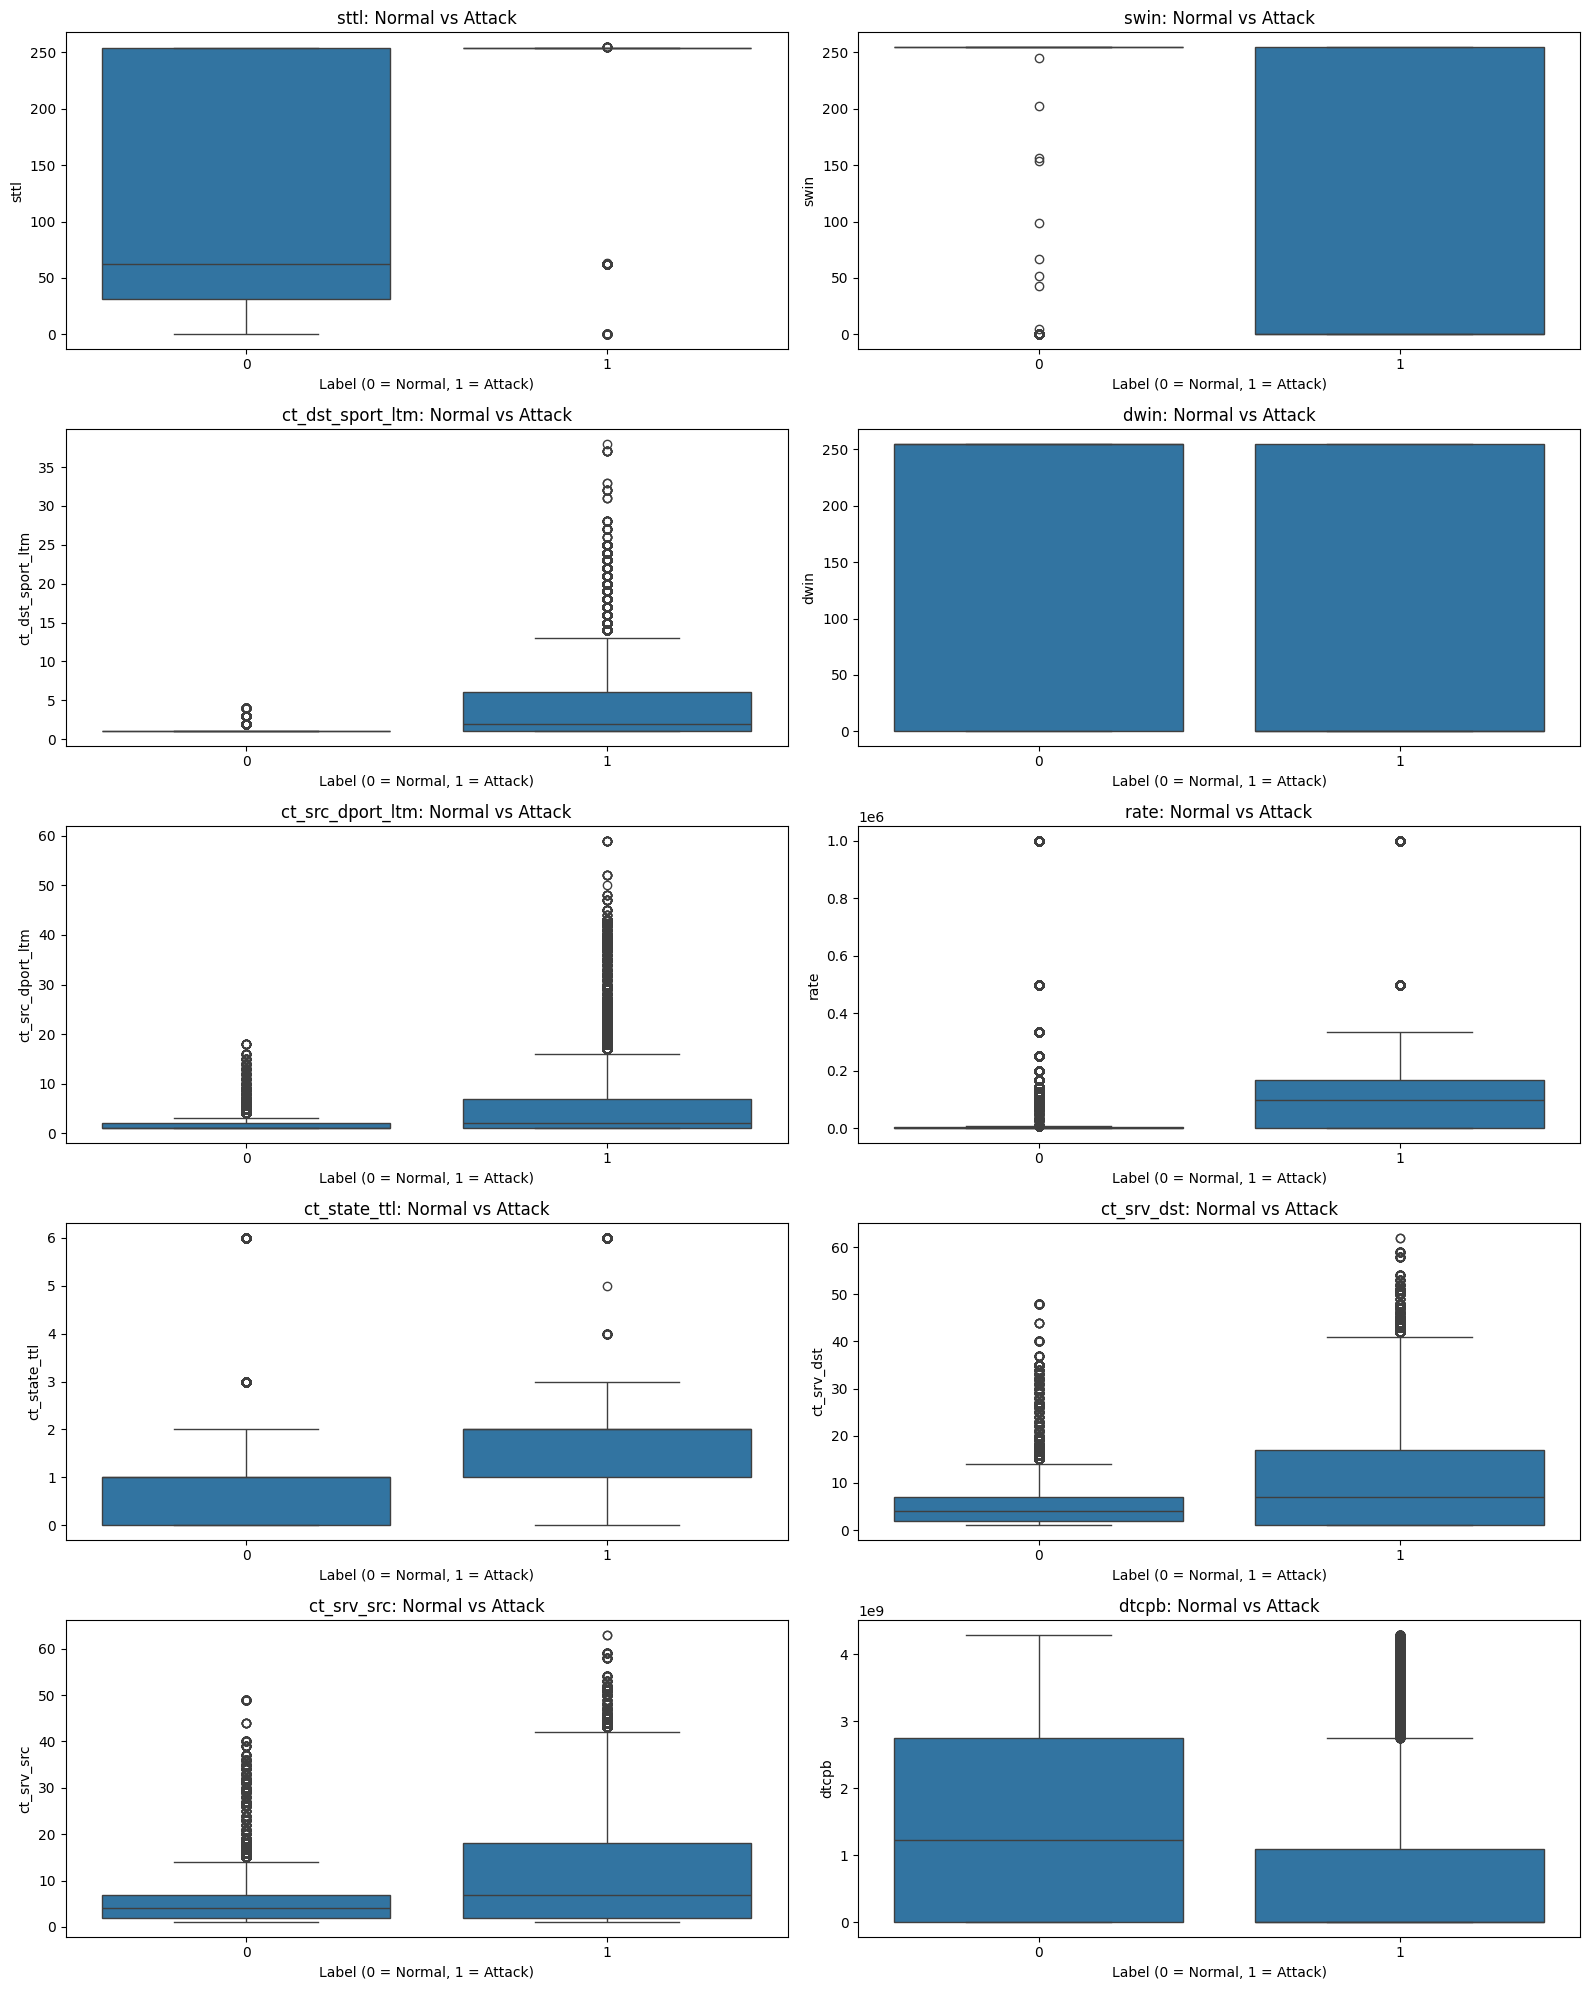

In [38]:
fig, axes = plt.subplots(
    5,
    2,
    figsize=(16, 20)
)

axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    
    sns.boxplot(
        data=train_df,
        x="label",
        y=feature,
        ax=ax
    )
    
    ax.set_title(
        f"{feature}: Normal vs Attack"
    )
    
    ax.set_xlabel("Label (0 = Normal, 1 = Attack)")

plt.tight_layout()
plt.show()

In [39]:
# comapre categorical features with attack label
for col in categorical_features:
    
    attack_rate = (
        train_df
        .groupby(col)["label"]
        .agg(["count", "mean"])
        .rename(
            columns={"mean": "attack_rate"}
        )
        .sort_values(
            "attack_rate",
            ascending=False
        )
    )
    
    print(f"\n{'='*60}")
    print(f"ATTACK RATE BY {col.upper()}")
    print(f"{'='*60}")
    
    display(attack_rate.head(20))


ATTACK RATE BY PROTO


,count,attack_rate
proto,,
3pc,32,1.0000
a/n,32,1.0000
aes-sp3-d,32,1.0000
any,96,1.0000
argus,33,1.0000
aris,32,1.0000
ax.25,32,1.0000
bna,32,1.0000
bbn-rcc,34,1.0000



ATTACK RATE BY SERVICE


,count,attack_rate
service,,
dhcp,26,1.0000
snmp,29,1.0000
ssl,30,1.0000
pop3,423,1.0000
irc,5,1.0000
dns,21367,0.8564
radius,9,0.7778
smtp,1851,0.6569
http,8287,0.5157



ATTACK RATE BY STATE


,count,attack_rate
state,,
CLO,1,1.0000
INT,34163,0.8687
ACC,4,0.5000
FIN,39339,0.3855
REQ,1842,0.0733
CON,6982,0.0500
RST,1,0.0000


In [40]:
# correlation analysis
correlation_matrix = train_df[numerical_features].corr()

correlation_matrix

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
dur,1.0000,0.2802,0.2175,0.2254,0.1725,-0.1180,-0.0010,0.0900,-0.0763,-0.0470,0.2401,0.1712,0.0798,0.1508,0.1466,0.1654,0.0840,0.0445,0.0453,0.0612,0.0753,0.0665,0.0731,0.0905,0.0436,0.0060,0.0762,-0.0883,0.0939,-0.0726,-0.0869,-0.0816,-0.0711,0.0157,0.0155,0.0189,-0.0808,-0.0913,0.0275
spkts,0.2802,1.0000,0.3696,0.9657,0.1983,-0.0682,-0.0925,0.0546,-0.0442,0.0744,0.9736,0.1987,-0.0145,-0.0033,-0.0024,0.0105,0.1118,0.0836,0.0862,0.1162,0.0099,0.0042,0.0155,0.1930,0.1410,0.0068,0.0856,-0.0587,-0.0739,-0.0479,-0.0531,-0.0551,-0.0619,0.0104,0.0104,0.0004,-0.0494,-0.0588,-0.0140
dpkts,0.2175,0.3696,1.0000,0.1758,0.9764,-0.0832,-0.1638,0.0365,-0.0541,0.1338,0.1891,0.9815,-0.0171,-0.0072,-0.0039,0.0343,0.1415,0.1103,0.1073,0.1475,-0.0070,-0.0110,-0.0006,0.0125,0.3960,0.0267,0.3580,-0.0628,-0.1224,-0.0526,-0.0625,-0.0675,-0.0750,0.0125,0.0126,0.0210,-0.0574,-0.0632,-0.0161
sbytes,0.2254,0.9657,0.1758,1.0000,0.0100,-0.0251,-0.0179,0.0499,-0.0152,-0.0064,0.9950,0.0071,-0.0054,-0.0014,-0.0027,-0.0031,0.0414,0.0287,0.0331,0.0433,0.0168,0.0107,0.0216,0.2067,-0.0032,0.0003,0.0017,-0.0302,-0.0073,-0.0223,-0.0206,-0.0205,-0.0241,-0.0026,-0.0026,-0.0046,-0.0215,-0.0300,-0.0049
dbytes,0.1725,0.1983,0.9764,0.0100,1.0000,-0.0480,-0.1145,0.0125,-0.0313,0.1009,0.0146,0.9971,-0.0102,-0.0073,-0.0052,0.0292,0.0830,0.0645,0.0613,0.0865,-0.0126,-0.0148,-0.0075,-0.0305,0.3754,0.0285,0.3827,-0.0343,-0.0730,-0.0296,-0.0353,-0.0390,-0.0440,-0.0065,-0.0065,0.0229,-0.0333,-0.0344,-0.0093
rate,-0.1180,-0.0682,-0.0832,-0.0251,-0.0480,1.0000,0.3882,-0.4539,0.5501,-0.1384,-0.0401,-0.0621,-0.0657,-0.0522,-0.0620,-0.0816,-0.5341,-0.4285,-0.4270,-0.5531,-0.2672,-0.2289,-0.2683,-0.1098,-0.2593,-0.0961,-0.0232,0.3677,0.3995,0.3110,0.3456,0.3662,0.3589,-0.0501,-0.0500,-0.1124,0.3276,0.3708,-0.0587
sttl,-0.0010,-0.0925,-0.1638,-0.0179,-0.1145,0.3882,1.0000,-0.0333,0.2529,-0.3862,-0.0381,-0.1377,-0.1793,-0.0062,0.0301,-0.0841,-0.3705,-0.3057,-0.3048,-0.3984,-0.0180,-0.0189,-0.0136,0.0011,-0.5320,-0.1243,-0.0549,0.3115,0.5561,0.2207,0.2876,0.3158,0.3351,-0.0896,-0.0899,-0.1748,0.2369,0.3041,-0.1879
dttl,0.0900,0.0546,0.0365,0.0499,0.0125,-0.4539,-0.0333,1.0000,-0.2939,-0.1395,0.0612,0.0220,-0.0756,0.0907,0.1406,0.1138,0.7499,0.6098,0.6087,0.7820,0.6439,0.5508,0.6476,0.1684,0.1083,0.1629,0.0054,-0.4447,-0.2302,-0.3769,-0.3499,-0.3578,-0.3642,0.0522,0.0509,0.2086,-0.4033,-0.4546,-0.0870
sload,-0.0763,-0.0442,-0.0541,-0.0152,-0.0313,0.5501,0.2529,-0.2939,1.0000,-0.0928,-0.0259,-0.0405,-0.0417,-0.0338,-0.0400,-0.0528,-0.3615,-0.2783,-0.2772,-0.3591,-0.1729,-0.1481,-0.1736,0.2547,-0.1696,-0.0622,-0.0150,0.1586,0.2333,0.0903,0.1124,0.0834,0.1554,-0.0326,-0.0325,-0.0728,0.1100,0.1603,-0.0380
dload,-0.0470,0.0744,0.1338,-0.0064,0.1009,-0.1384,-0.3862,-0.1395,-0.0928,1.0000,0.0092,0.1173,-0.0321,-0.0245,-0.0288,-0.0313,0.2228,0.1764,0.1820,0.2333,-0.1208,-0.1034,-0.1213,-0.0838,0.5409,-0.0321,0.0255,-0.0542,-0.3324,-0.0697,-0.1121,-0.1183,-0.1317,-0.0189,-0.0187,-0.0411,-0.0660,-0.0590,-0.0279


In [41]:
# highly correlated pairs 
correlation_pairs = (
    correlation_matrix
    .abs()
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        ascending=False
    )
)

high_correlation_pairs = correlation_pairs[
    correlation_pairs > 0.90
]

high_correlation_pairs

dbytes            dloss              0.9971
sbytes            sloss              0.9950
is_ftp_login      ct_ftp_cmd         0.9943
dpkts             dloss              0.9815
ct_srv_src        ct_srv_dst         0.9778
dpkts             dbytes             0.9764
spkts             sloss              0.9736
                  sbytes             0.9657
ct_dst_ltm        ct_src_dport_ltm   0.9604
swin              dwin               0.9601
sinpkt            is_sm_ips_ports    0.9445
ct_dst_src_ltm    ct_srv_dst         0.9410
tcprtt            synack             0.9395
ct_srv_src        ct_dst_src_ltm     0.9338
ct_src_dport_ltm  ct_src_ltm         0.9332
ct_dst_ltm        ct_src_ltm         0.9323
ct_src_dport_ltm  ct_dst_sport_ltm   0.9116
dtype: float64

# Preprocessing Pipeline Testing

In [47]:
# import and split 
from src.data.preprocessing import UNSWPreprocessor

preprocessor = UNSWPreprocessor()

X_train, y_train, attack_train = (
    preprocessor.split_features_and_target(train_df)
)

X_test, y_test, attack_test = (
    preprocessor.split_features_and_target(test_df)
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("attack_train:", attack_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)
print("attack_test:", attack_test.shape)

X_train: (82332, 42)
y_train: (82332,)
attack_train: (82332,)

X_test: (175341, 42)
y_test: (175341,)
attack_test: (175341,)


In [50]:
# preprocessing pipeline 
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original train:", X_train.shape)
print("Processed train:", X_train_processed.shape)

print("\nOriginal test:", X_test.shape)
print("Processed test:", X_test_processed.shape)

Original train: (82332, 42)
Processed train: (82332, 190)

Original test: (175341, 42)
Processed test: (175341, 190)


In [ ]:
# verify feature identification
print("Numerical features:")
print(preprocessor.numerical_features)

print("\nNumber of numerical features:")
print(len(preprocessor.numerical_features))

print("\nCategorical features:")
print(preprocessor.categorical_features)

print("\nNumber of categorical features:")
print(len(preprocessor.categorical_features))

Numerical features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Number of numerical features:
39

Categorical features:
['proto', 'service', 'state']

Number of categorical features:
3


In [53]:
# assertion 
assert (
    X_train_processed.shape[1]
    ==
    X_test_processed.shape[1]
), "Train and test have different feature spaces!"

print("Train and test feature spaces match.")

Train and test feature spaces match.


In [54]:
#check generated feature names
feature_names = preprocessor.transformer.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20:")
print(feature_names[:20])

print("\nLast 20:")
print(feature_names[-20:])

Number of processed features: 190

First 20:
['numeric__dur' 'numeric__spkts' 'numeric__dpkts' 'numeric__sbytes'
 'numeric__dbytes' 'numeric__rate' 'numeric__sttl' 'numeric__dttl'
 'numeric__sload' 'numeric__dload' 'numeric__sloss' 'numeric__dloss'
 'numeric__sinpkt' 'numeric__dinpkt' 'numeric__sjit' 'numeric__djit'
 'numeric__swin' 'numeric__stcpb' 'numeric__dtcpb' 'numeric__dwin']

Last 20:
['categorical__service_-' 'categorical__service_dhcp'
 'categorical__service_dns' 'categorical__service_ftp'
 'categorical__service_ftp-data' 'categorical__service_http'
 'categorical__service_irc' 'categorical__service_pop3'
 'categorical__service_radius' 'categorical__service_smtp'
 'categorical__service_snmp' 'categorical__service_ssh'
 'categorical__service_ssl' 'categorical__state_ACC'
 'categorical__state_CLO' 'categorical__state_CON'
 'categorical__state_FIN' 'categorical__state_INT'
 'categorical__state_REQ' 'categorical__state_RST']


In [56]:
#sanity checks
assert X_train.shape[1] == 42
assert X_test.shape[1] == 42

assert "label" not in X_train.columns
assert "attack_cat" not in X_train.columns
assert "id" not in X_train.columns

assert len(preprocessor.numerical_features) == 39
assert len(preprocessor.categorical_features) == 3

print("All preprocessing sanity checks passed.")

All preprocessing sanity checks passed.
